In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [75]:
#extracting sentiment score out of the dataframe 
df=pd.read_csv('df_sampled_sentiment.csv')
#convert to datetime cause csv doesn't save formats
from dateutil import tz
print(df['video_published_at'].iloc[0])
et=tz.gettz("US/Eastern")

df['comment_published_at']=pd.to_datetime(df['comment_published_at'], utc=True).dt.tz_convert(et)
df['video_published_at']=pd.to_datetime(df['video_published_at'], utc=True).dt.tz_convert(et)
#checking the timezone
print(df.info())
#sorting it as a necessary step for merge_asof()
df.sort_values("comment_published_at", inplace=True)
df

2023-11-07 07:11:54-05:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4050 entries, 0 to 4049
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype                                                   
---  ------                --------------  -----                                                   
 0   Unnamed: 0            4050 non-null   int64                                                   
 1   comment               4050 non-null   object                                                  
 2   likes                 4050 non-null   int64                                                   
 3   comment_published_at  4050 non-null   datetime64[ns, tzfile('/usr/share/zoneinfo/US/Eastern')]
 4   video_title           4050 non-null   object                                                  
 5   video_published_at    4050 non-null   datetime64[ns, tzfile('/usr/share/zoneinfo/US/Eastern')]
 6   video_url             4050 non-null   object                  

,Unnamed: 0,comment,likes,comment_published_at,video_title,video_published_at,video_url,month-year,lang,comment_sentiment
3662,572,Me: sees M3 refresh video\n\nMe: *clicks*,2,2023-09-07 06:13:53-04:00,NEW Tesla Model 3 facelift REVIEW! Everything ...,2023-09-06 03:00:13-04:00,https://www.youtube.com/watch?v=Fd1wpNkv-Nw,September-2023,en,0.145560
3615,571,"No stalks, no thanks",1,2023-09-07 07:10:51-04:00,NEW Tesla Model 3 facelift REVIEW! Everything ...,2023-09-06 03:00:13-04:00,https://www.youtube.com/watch?v=Fd1wpNkv-Nw,September-2023,en,-0.458909
3609,570,"No HUD, no buy.",1,2023-09-07 08:27:51-04:00,NEW Tesla Model 3 facelift REVIEW! Everything ...,2023-09-06 03:00:13-04:00,https://www.youtube.com/watch?v=Fd1wpNkv-Nw,September-2023,tl,-0.486150
3691,569,Quality is still the same as a £20k car. Sad b...,2,2023-09-07 08:37:17-04:00,NEW Tesla Model 3 facelift REVIEW! Everything ...,2023-09-06 03:00:13-04:00,https://www.youtube.com/watch?v=Fd1wpNkv-Nw,September-2023,en,-0.734243
3734,568,"The ""wish list"" item you missed is ... POWERED...",2,2023-09-07 08:51:26-04:00,NEW Tesla Model 3 facelift REVIEW! Everything ...,2023-09-06 03:00:13-04:00,https://www.youtube.com/watch?v=Fd1wpNkv-Nw,September-2023,en,-0.005326
...,...,...,...,...,...,...,...,...,...,...
3075,8877,🥱🥱🥱.,0,2025-11-17 06:43:55-05:00,101 Facts About TESLA,2025-05-01 06:10:29-04:00,https://www.youtube.com/watch?v=ZvFcA4_9nkw,November-2025,unkown,-0.031673
3082,8874,This isn't YOUR car at all. You only pay for i...,0,2025-11-17 07:15:50-05:00,101 Facts About TESLA,2025-05-01 06:10:29-04:00,https://www.youtube.com/watch?v=ZvFcA4_9nkw,November-2025,en,-0.751580
3066,9073,This is actually so well made.,0,2025-11-17 07:31:14-05:00,Tesla Delivers Itself to New Owner,2025-06-28 00:48:53-04:00,https://www.youtube.com/watch?v=GU16hXSSGKs,November-2025,en,0.967453
3003,8873,Ehhhhh no thanks,0,2025-11-17 08:02:18-05:00,101 Facts About TESLA,2025-05-01 06:10:29-04:00,https://www.youtube.com/watch?v=ZvFcA4_9nkw,November-2025,en,-0.454980


In [76]:
#df_tsla = yf.download("TSLA", start="2023-09-01", end="2025-10-31")
df_tsla=pd.read_csv("tsla_20230901-20251031.csv")
df_tsla=df_tsla[['Date', 'Close']]
df_tsla

,Date,Close
0,2023-09-01,245.009995
1,2023-09-05,256.489990
2,2023-09-06,251.919998
3,2023-09-07,251.490005
4,2023-09-08,248.500000
...,...,...
538,2025-10-24,433.720001
539,2025-10-27,452.420013
540,2025-10-28,460.549988
541,2025-10-29,461.510010






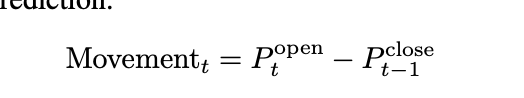

But instead of this we use the relative difference
=



In [77]:
#keep only closing and counting the difference
df_tesla_processed=df_tsla
print(df_tesla_processed)
df_tesla_processed.columns=["Stock_Date",'Closing Price($)']
print(df_tesla_processed)
df_tesla_processed.loc[1:,'relative difference']=(df_tesla_processed['Closing Price($)']/(df_tesla_processed['Closing Price($)'].shift(1)))-1
df_tesla_processed.sort_values('Stock_Date', inplace=True)
df_tesla_processed['Stock_Date']=pd.to_datetime(df_tesla_processed['Stock_Date']).dt.tz_localize(et)
df_tesla_processed.to_parquet("tesla_financial_data.parquet")
df_tesla_processed

           Date       Close
0    2023-09-01  245.009995
1    2023-09-05  256.489990
2    2023-09-06  251.919998
3    2023-09-07  251.490005
4    2023-09-08  248.500000
..          ...         ...
538  2025-10-24  433.720001
539  2025-10-27  452.420013
540  2025-10-28  460.549988
541  2025-10-29  461.510010
542  2025-10-30  440.100006

[543 rows x 2 columns]
     Stock_Date  Closing Price($)
0    2023-09-01        245.009995
1    2023-09-05        256.489990
2    2023-09-06        251.919998
3    2023-09-07        251.490005
4    2023-09-08        248.500000
..          ...               ...
538  2025-10-24        433.720001
539  2025-10-27        452.420013
540  2025-10-28        460.549988
541  2025-10-29        461.510010
542  2025-10-30        440.100006

[543 rows x 2 columns]


,Stock_Date,Closing Price($),relative difference
0,2023-09-01 00:00:00-04:00,245.009995,NaN
1,2023-09-05 00:00:00-04:00,256.489990,0.046855
2,2023-09-06 00:00:00-04:00,251.919998,-0.017817
3,2023-09-07 00:00:00-04:00,251.490005,-0.001707
4,2023-09-08 00:00:00-04:00,248.500000,-0.011889
...,...,...,...
538,2025-10-24 00:00:00-04:00,433.720001,-0.033988
539,2025-10-27 00:00:00-04:00,452.420013,0.043115
540,2025-10-28 00:00:00-04:00,460.549988,0.017970
541,2025-10-29 00:00:00-04:00,461.510010,0.002085


In [78]:
df["YYYY-MM-DD"]=df['comment_published_at'].dt.strftime("%Y-%m-%d")
# df_grouped=df.groupby("YYYY-MM-DD").agg(
#                                       number_of_comments_at_date=('comment','count' ),
#                                       comment_likes_agg=('likes','sum'), 
#                                       comment_sentiment_agg=('comment_sentiment','mean')
# )
#df_grouped = df_grouped.reset_index()
df_tesla_processed['YYYY-MM-DD']=df_tesla_processed['Stock_Date'].dt.strftime("%Y-%m-%d")
df['YYYY-MM-DD']=pd.to_datetime(df['YYYY-MM-DD'], utc=True)
df_tesla_processed['YYYY-MM-DD']=pd.to_datetime(df_tesla_processed['YYYY-MM-DD'], utc=True)
#sorting in ascending chronological order
df.sort_values("YYYY-MM-DD", inplace=True)
df_tesla_processed.sort_values("YYYY-MM-DD",inplace=True)

Yahoo Finance uses the exchange’s local time. so we just use tz_localize(et)


In [79]:
df_merged_forward=pd.merge(df, df_tesla_processed, left_on='YYYY-MM-DD', right_on='YYYY-MM-DD',suffixes=("_sentiment", "_tslastock"))
#saving it as unaggregated dataframe
df_merged_forward = df_merged_forward.rename(columns={'published_at': 'comment_published_at'})
df_merged_forward.columns
#creating a lag for the Closing Price and relative difference
df_merged_forward["Closing Price($) lag 1"]=df_merged_forward['Closing Price($)'].shift(1)
df_merged_forward["relative difference lag 1"]=df_merged_forward["relative difference"].shift(1)




In [80]:
print(f"Correlation from todays sentiment and tomorrow's stock: \n {df_merged_forward[['comment_sentiment', 'relative difference']].corr()}")
print(f"Correlation from todays sentiment and todays stock (lag1): \n {df_merged_forward[['comment_sentiment', 'relative difference lag 1']].corr()}")

Correlation from todays sentiment and tomorrow's stock: 
                      comment_sentiment  relative difference
comment_sentiment             1.000000             0.001649
relative difference           0.001649             1.000000
Correlation from todays sentiment and todays stock (lag1): 
                            comment_sentiment  relative difference lag 1
comment_sentiment                   1.000000                   0.017547
relative difference lag 1           0.017547                   1.000000


In [81]:
df_merged_forward.columns

Index(['Unnamed: 0', 'comment', 'likes', 'comment_published_at', 'video_title',
       'video_published_at', 'video_url', 'month-year', 'lang',
       'comment_sentiment', 'YYYY-MM-DD', 'Stock_Date', 'Closing Price($)',
       'relative difference', 'Closing Price($) lag 1',
       'relative difference lag 1'],
      dtype='object')

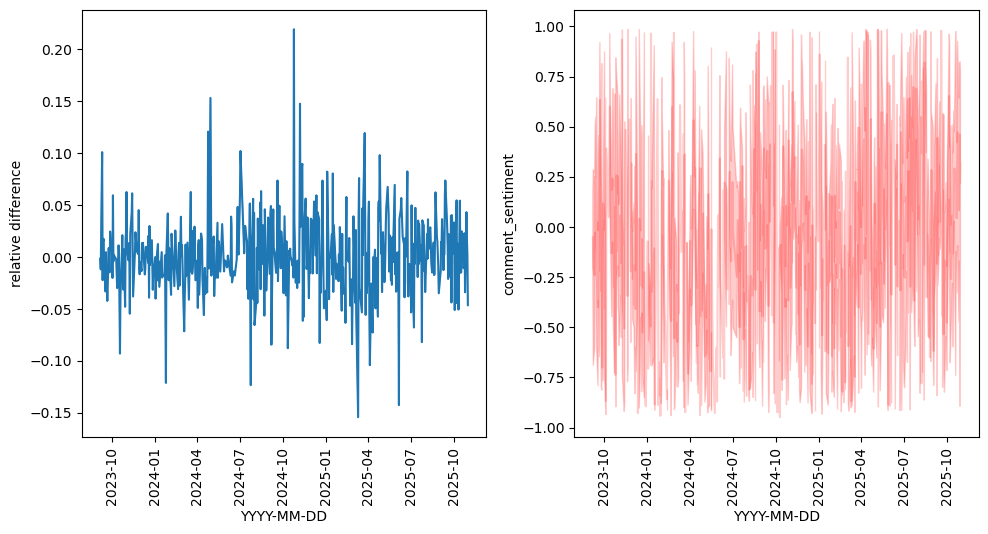

In [82]:
fig, ax=plt.subplots(1, 2, figsize=(10,5))

sns.lineplot(ax=ax[0], data=df_merged_forward, x='YYYY-MM-DD', y='relative difference')
sns.lineplot(ax=ax[1], data=df_merged_forward, x='YYYY-MM-DD', y='comment_sentiment', color='red', alpha=0.2)
plt.tight_layout()
[ax.tick_params(axis='x',rotation=90) for ax in ax.ravel()]
plt.show()

In [83]:
df_agg=df_merged_forward.groupby(df_merged_forward['comment_published_at'].dt.to_period("M")).agg({'comment_sentiment':'mean','relative difference':'mean', 'relative difference lag 1':'mean'})
df_agg.reset_index(inplace=True)
df_agg.rename(columns={"comment_sentiment":"sentiment_score"}, inplace=True)
print(df_agg)

   comment_published_at  sentiment_score  relative difference  \
0               2023-09        -0.030959            -0.000191   
1               2023-10        -0.040065            -0.010916   
2               2023-11        -0.083394             0.007144   
3               2023-12        -0.239934             0.000399   
4               2024-01        -0.309334            -0.004094   
5               2024-02        -0.051828            -0.001343   
6               2024-03        -0.367710            -0.026025   
7               2024-04        -0.247975            -0.024336   
8               2024-05        -0.444292            -0.000293   
9               2024-06         0.106385             0.002846   
10              2024-07        -0.074141             0.027715   
11              2024-08        -0.040183             0.002449   
12              2024-09         0.016608             0.009548   
13              2024-10        -0.121056             0.002213   
14              2024-11  

/var/folders/vq/lk7nh_yn6tb1b_v3zw2jkq1c0000gp/T/ipykernel_3127/4034180171.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_agg=df_merged_forward.groupby(df_merged_forward['comment_published_at'].dt.to_period("M")).agg({'comment_sentiment':'mean','relative difference':'mean', 'relative difference lag 1':'mean'})


In [84]:
print(f"Correlation from todays aggregated sentiment and tomorrow's stock: \n {df_agg[['sentiment_score', 'relative difference', 'relative difference lag 1']].corr()}")

Correlation from todays aggregated sentiment and tomorrow's stock: 
                            sentiment_score  relative difference  \
sentiment_score                   1.000000             0.247896   
relative difference               0.247896             1.000000   
relative difference lag 1         0.237002             0.999032   

                           relative difference lag 1  
sentiment_score                             0.237002  
relative difference                         0.999032  
relative difference lag 1                   1.000000  


In [85]:
df_lag = df_agg[['relative difference', 'sentiment_score']].dropna()
max_lag = 10
lags = range(-max_lag, max_lag + 1)

correlations = []

for lag in lags:
    corr = df_lag['sentiment_score'].shift(lag).corr(df_lag['relative difference'])
    correlations.append(corr)

ccf_df = pd.DataFrame({'lag': lags, 'correlation': correlations})

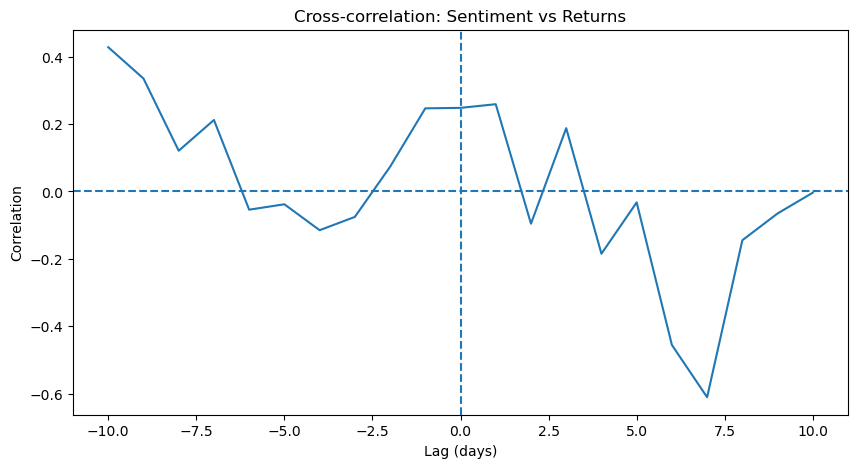

In [86]:
plt.figure(figsize=(10, 5))
plt.plot(ccf_df['lag'], ccf_df['correlation'])
plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')
plt.title("Cross-correlation: Sentiment vs Returns")
plt.xlabel("Lag (days)")
plt.ylabel("Correlation")
plt.show()

,sentiment_score,relative difference
sentiment_score,1.000000,0.247896
relative difference,0.247896,1.000000


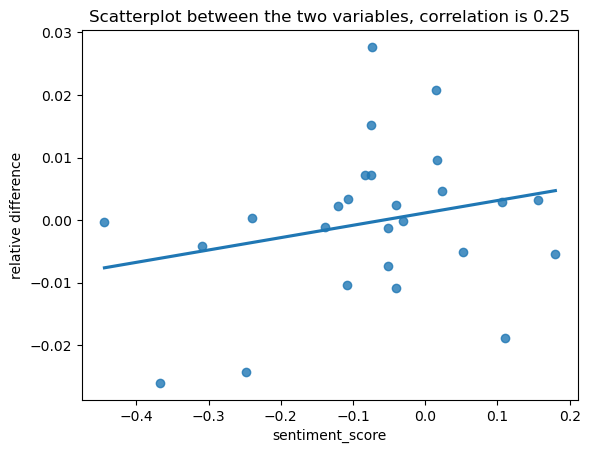

In [87]:
sns.regplot(data=df_agg, x='sentiment_score',y='relative difference',ci=None)
plt.title("Scatterplot between the two variables, correlation is 0.25")
df_agg[['sentiment_score','relative difference']].corr()

In [88]:
#filtering only 24 month untill august 2025
df_agg=df_agg[df_agg['comment_published_at']<="2025-08-31"]

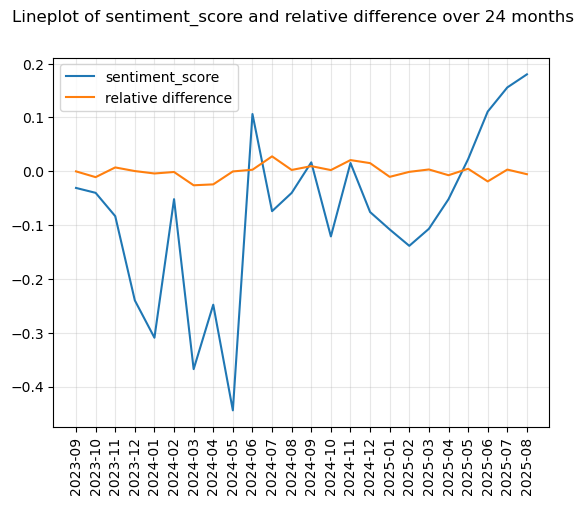

In [89]:
#creating a stack plot in order to see how the two evolve over time.
x_ticks_for_stackplot=np.arange(len(df_agg['comment_published_at']))
plt.plot(x_ticks_for_stackplot,df_agg['sentiment_score'], label='sentiment_score')
plt.plot(x_ticks_for_stackplot,df_agg['relative difference'], label='relative difference' )
plt.xticks(x_ticks_for_stackplot[::1], df_agg['comment_published_at'][::1], rotation=90)
plt.legend()
plt.suptitle("Lineplot of sentiment_score and relative difference over 24 months")
plt.grid(axis='both', alpha=0.3)

In [90]:
df_agg['norm_relative difference']=2*(df_agg['relative difference']-df_agg['relative difference'].min())/(df_agg['relative difference'].max()-df_agg['relative difference'].min())-1
df_agg['norm_sentiment_score']=2*(df_agg['sentiment_score']-df_agg['sentiment_score'].min())/(df_agg['sentiment_score'].max()-df_agg['sentiment_score'].min())-1


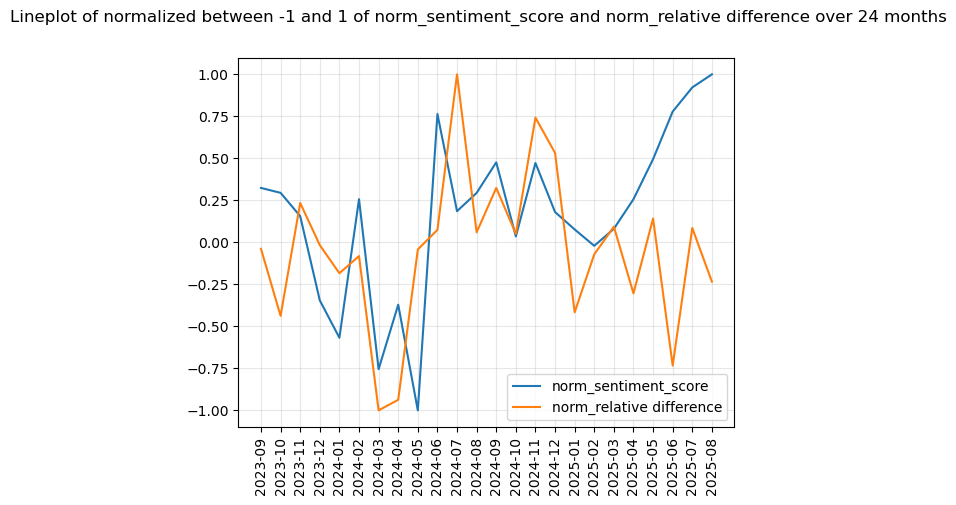

In [91]:
x_ticks_for_stackplot=np.arange(len(df_agg['comment_published_at']))
plt.plot(x_ticks_for_stackplot,df_agg['norm_sentiment_score'], label='norm_sentiment_score')
plt.plot(x_ticks_for_stackplot,df_agg['norm_relative difference'], label='norm_relative difference' )
plt.xticks(x_ticks_for_stackplot[::1], df_agg['comment_published_at'][::1], rotation=90)
plt.legend()
plt.suptitle("Lineplot of normalized between -1 and 1 of norm_sentiment_score and norm_relative difference over 24 months")
plt.grid(axis='both', alpha=0.3)

Relative difference is already lag1 because of merging with merge as of. The sentiment is computet on 7th of August for example and the return is computed for 8th of August. There is a one day difference. 

Very important in the next steps is to set the label and decide on the features thath will enter the modelling phase. For the featuures a data leackage should be avoided including always lag1 values from the stock market. Such as the return (relative price) or Closing price. 

The target value should be the return on that day so that an investor know based on yesterdays sentiment how they should invest on the stock market. 
This means that the target value should be relative difference.
